In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Chest X-ray Disease Classification using Deep Learning

## Overview

This project develops a deep learning system for multi-label chest X-ray disease classification using the CheXpert dataset.

A pretrained DenseNet121 model is fine-tuned to identify five clinically important thoracic diseases from frontal chest radiographs.

The project follows an end-to-end machine learning workflow including:

- Data preprocessing
- Image augmentation
- Multi-label classification
- Model training
- Performance evaluation
- Visual analysis of predictions

**Dataset:** Stanford CheXpert

**Framework:** PyTorch

**Primary Evaluation Metric:** Mean ROC-AUC

## Project Objectives

The objectives of this project are:

- Build a robust multi-label chest X-ray classification model.
- Detect five major thoracic diseases simultaneously.
- Evaluate model performance using ROC-AUC and classification metrics.
- Create a reproducible deep learning pipeline suitable for research and deployment.

## Import Required Libraries

This section imports the Python libraries used throughout the notebook. These include tools for data handling, model loading, image preprocessing, evaluation metrics, and visualization.

In [2]:
# Code 1: Import the required libraries

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from tqdm.auto import tqdm

# Use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch Version : {torch.__version__}")
print(f"Device          : {DEVICE}")

PyTorch Version : 2.11.0+cu128
Device          : cuda


## Project Paths

This section defines the locations of the dataset, trained model, and output folders used during evaluation. Keeping all paths in one place makes the notebook easier to maintain and update.

In [3]:
# Code 2: Define project paths

from pathlib import Path

# Root project directory
PROJECT_DIR = Path("/content/drive/MyDrive/ChestXRay_Project")

# Dataset
DATASET_DIR = PROJECT_DIR / "dataset"

# Metadata files
TRAIN_CSV = DATASET_DIR / "train.csv"
VALID_CSV = DATASET_DIR / "valid.csv"

# Image folders
TRAIN_IMAGES_DIR = DATASET_DIR / "train"
VALID_IMAGES_DIR = DATASET_DIR / "valid"

# Saved model
MODEL_PATH = PROJECT_DIR / "best_densenet121.pth"

# Output folders
OUTPUTS_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METRICS_DIR = OUTPUTS_DIR / "metrics"

# Create output folders if needed
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model found: {MODEL_PATH.exists()}")
print(f"Model path : {MODEL_PATH}")

Model found: True
Model path : /content/drive/MyDrive/ChestXRay_Project/best_densenet121.pth


In [4]:
# Code 2: Find the dataset ZIP file in Google Drive

from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

zip_files = list(drive_root.rglob("*.zip"))

print(f"Found {len(zip_files)} ZIP file(s):\n")

for i, file in enumerate(zip_files, start=1):
    print(f"{i}. {file}")

Found 1 ZIP file(s):

1. /content/drive/MyDrive/ChestXRay Data.zip


## Extract the Dataset

The CheXpert dataset is stored as a ZIP file in Google Drive. We extract it to the Colab runtime so image loading is faster during model evaluation.

In [5]:
# Code 3: Extract the CheXpert dataset

from pathlib import Path
import zipfile

# Path to the dataset ZIP file in Google Drive
ZIP_PATH = Path("/content/drive/MyDrive/ChestXRay Data.zip")

# Extract the dataset into the Colab runtime
EXTRACT_DIR = Path("/content/ChestXRay_Dataset")

# Extract only if it hasn't been extracted already
if not EXTRACT_DIR.exists():
    print("Extracting dataset... This may take a few minutes.")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Dataset extracted successfully.")
else:
    print("Dataset is already available.")

print(f"Dataset location: {EXTRACT_DIR}")

Extracting dataset... This may take a few minutes.
Dataset extracted successfully.
Dataset location: /content/ChestXRay_Dataset


In [6]:
# Code 4: Inspect the extracted dataset

from pathlib import Path

dataset_root = Path("/content/ChestXRay_Dataset")

print("Contents of the extracted folder:\n")

for item in sorted(dataset_root.iterdir()):
    print(item)

Contents of the extracted folder:

/content/ChestXRay_Dataset/train
/content/ChestXRay_Dataset/train.csv
/content/ChestXRay_Dataset/valid
/content/ChestXRay_Dataset/valid.csv


## Configure Dataset and Model Paths

This section defines the locations of the metadata files, image folders, and the trained DenseNet121 model. Keeping these paths together makes the notebook easier to maintain and update.

In [8]:
# Code 5: Configure dataset and model paths

from pathlib import Path

# Dataset root directory
DATASET_DIR = Path("/content/ChestXRay_Dataset")

# Metadata files
TRAIN_CSV = DATASET_DIR / "train.csv"
VALID_CSV = DATASET_DIR / "valid.csv"

# Image directories
TRAIN_IMAGES_DIR = DATASET_DIR / "train"
VALID_IMAGES_DIR = DATASET_DIR / "valid"

# Saved model
MODEL_PATH = Path("/content/drive/MyDrive/ChestXRay_Project/best_densenet121.pth")

print(f"Training CSV     : {TRAIN_CSV}")
print(f"Validation CSV   : {VALID_CSV}")
print(f"Training Images  : {TRAIN_IMAGES_DIR}")
print(f"Validation Images: {VALID_IMAGES_DIR}")
print(f"Saved Model      : {MODEL_PATH}")

print(f"\nModel Found: {MODEL_PATH.exists()}")

Training CSV     : /content/ChestXRay_Dataset/train.csv
Validation CSV   : /content/ChestXRay_Dataset/valid.csv
Training Images  : /content/ChestXRay_Dataset/train
Validation Images: /content/ChestXRay_Dataset/valid
Saved Model      : /content/drive/MyDrive/ChestXRay_Project/best_densenet121.pth

Model Found: True


## Load the Trained DenseNet121 Model

In this section, we recreate the same DenseNet121 architecture used during training and load the best-performing model saved in Google Drive. The model is then switched to evaluation mode so it can be used for inference.

In [9]:
# Code 6: Rebuild DenseNet121 and load the trained weights

import torch
import torchvision.models as models

# Create the same DenseNet121 architecture used during training
model = models.densenet121(weights=None)

# Replace the final classifier with a 5-class output layer
num_features = model.classifier.in_features
model.classifier = torch.nn.Linear(num_features, 5)

# Load the trained weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

# Move the model to the selected device
model = model.to(DEVICE)

# Switch to evaluation mode
model.eval()

print("✅ DenseNet121 loaded successfully.")
print(f"Running on: {DEVICE}")

✅ DenseNet121 loaded successfully.
Running on: cuda


## Prepare the Validation Dataset

This section loads the validation metadata, selects the target disease labels, and applies the same image preprocessing pipeline used during training. Using identical preprocessing ensures that model evaluation is consistent with the training process.

In [10]:
# Code 7: Load validation metadata and create the validation dataset

import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

# Target diseases used during training
TARGET_DISEASES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

# Load validation metadata
valid_df = pd.read_csv(VALID_CSV)

# Replace uncertain labels (-1) with positive labels (1)
valid_df[TARGET_DISEASES] = valid_df[TARGET_DISEASES].replace(-1, 1)

# Replace missing labels with negative labels (0)
valid_df[TARGET_DISEASES] = valid_df[TARGET_DISEASES].fillna(0)

# Image preprocessing (same as training)
validation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class CheXpertDataset(Dataset):
    """Dataset class for loading CheXpert chest X-ray images."""

    def __init__(self, dataframe, image_root, transform=None):
        self.dataframe = dataframe
        self.image_root = image_root
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = self.image_root / row["Path"].replace("CheXpert-v1.0-small/valid/", "")

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = row[TARGET_DISEASES].values.astype("float32")

        return image, torch.tensor(labels)


# Create the validation dataset
validation_dataset = CheXpertDataset(
    dataframe=valid_df,
    image_root=VALID_IMAGES_DIR,
    transform=validation_transform
)

print(f"Validation samples: {len(validation_dataset):,}")

Validation samples: 234


In [11]:
print(valid_df.iloc[0]["Path"])

CheXpert-v1.0-small/valid/patient64541/study1/view1_frontal.jpg


## Create the Validation DataLoader

This section creates a DataLoader for the validation dataset. The DataLoader loads images in batches, making inference more efficient while preserving the order of the samples for evaluation.

In [12]:
# Code 8: Create the validation DataLoader

from torch.utils.data import DataLoader

# Number of images processed in one batch
BATCH_SIZE = 32

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"Validation samples : {len(validation_dataset):,}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Total batches      : {len(validation_loader)}")

Validation samples : 234
Batch size         : 32
Total batches      : 8


## Generate Predictions on the Validation Set

This section runs the trained DenseNet121 model on the complete validation dataset. The predicted probabilities and ground truth labels are stored for calculating evaluation metrics and creating visualizations in the following sections.

In [13]:
# Code 9: Generate predictions on the validation dataset

from tqdm.auto import tqdm
import torch

# Store the ground truth labels and model predictions
all_labels = []
all_probabilities = []

# Disable gradient calculations during inference
model.eval()

with torch.no_grad():

    for images, labels in tqdm(validation_loader, desc="Running Inference"):

        # Move the batch to the selected device
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(images)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(outputs)

        # Store results on the CPU
        all_labels.append(labels.cpu())
        all_probabilities.append(probabilities.cpu())

# Combine all batches into single tensors
all_labels = torch.cat(all_labels, dim=0).numpy()
all_probabilities = torch.cat(all_probabilities, dim=0).numpy()

# Convert probabilities into binary predictions using a threshold of 0.5
all_predictions = (all_probabilities >= 0.5).astype(int)

print("Inference completed successfully.")
print(f"Validation samples : {len(all_labels)}")
print(f"Prediction shape   : {all_probabilities.shape}")

Running Inference:   0%|          | 0/8 [00:00<?, ?it/s]

Inference completed successfully.
Validation samples : 234
Prediction shape   : (234, 5)


## Evaluate Model Performance using AUROC

The Area Under the Receiver Operating Characteristic Curve (AUROC) measures the model's ability to distinguish between positive and negative cases. Since this is a multi-label classification task, AUROC is calculated separately for each disease along with the overall mean AUROC.

In [14]:
# Code 10: Calculate disease-wise and mean AUROC

from sklearn.metrics import roc_auc_score
import pandas as pd

# Store AUROC scores
auc_scores = {}

for index, disease in enumerate(TARGET_DISEASES):
    auc = roc_auc_score(
        all_labels[:, index],
        all_probabilities[:, index]
    )
    auc_scores[disease] = auc

# Mean AUROC
mean_auc = sum(auc_scores.values()) / len(auc_scores)

# Create a summary table
results_df = pd.DataFrame({
    "Disease": auc_scores.keys(),
    "AUROC": auc_scores.values()
})

results_df["AUROC"] = results_df["AUROC"].round(4)

print(results_df)

print(f"\nMean AUROC : {mean_auc:.4f}")

            Disease   AUROC
0       Atelectasis  0.8176
1      Cardiomegaly  0.8547
2     Consolidation  0.8973
3             Edema  0.9061
4  Pleural Effusion  0.9194

Mean AUROC : 0.8790


## Visualize Disease-wise AUROC

This visualization compares the AUROC achieved for each disease. The diseases are sorted by performance, making it easier to identify which conditions the model detects most accurately.

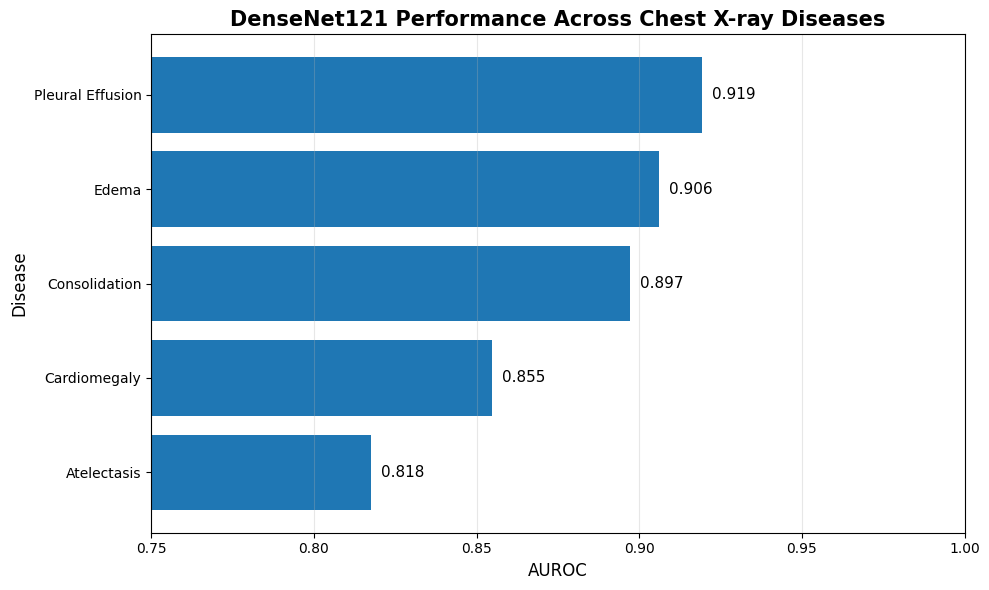

In [15]:
# Code 11: Visualize disease-wise AUROC

import matplotlib.pyplot as plt

# Sort diseases by AUROC
plot_df = results_df.sort_values("AUROC", ascending=True)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_df["Disease"],
    plot_df["AUROC"]
)

# Add AUROC value next to each bar
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=11
    )

plt.xlim(0.75, 1.00)

plt.xlabel("AUROC", fontsize=12)
plt.ylabel("Disease", fontsize=12)

plt.title(
    "DenseNet121 Performance Across Chest X-ray Diseases",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## Receiver Operating Characteristic (ROC) Curves

The ROC curve illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate across different classification thresholds.

Each curve represents one disease, while the Area Under the Curve (AUROC) summarizes the model's overall discriminative ability.

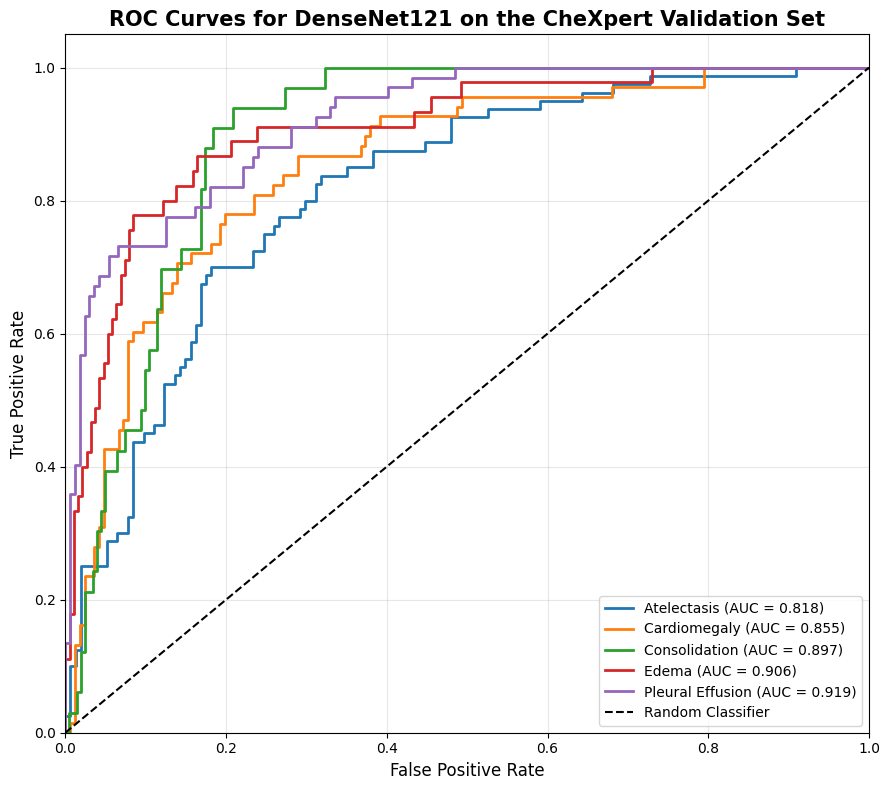

In [16]:
# Code 12: Plot ROC curves for all target diseases

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 8))

for index, disease in enumerate(TARGET_DISEASES):

    fpr, tpr, _ = roc_curve(
        all_labels[:, index],
        all_probabilities[:, index]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{disease} (AUC = {auc_scores[disease]:.3f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Random Classifier"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "ROC Curves for DenseNet121 on the CheXpert Validation Set",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Classification Metrics

While AUROC measures the model's ranking performance across all thresholds, precision, recall, F1-score, and accuracy evaluate its predictions using a fixed decision threshold of 0.5. Together, these metrics provide a more complete assessment of the model's classification performance for each disease.

In [17]:
# Code 13: Calculate classification metrics for each disease

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

metrics = []

for index, disease in enumerate(TARGET_DISEASES):

    y_true = all_labels[:, index]
    y_pred = all_predictions[:, index]

    metrics.append({
        "Disease": disease,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUROC": auc_scores[disease]
    })

metrics_df = pd.DataFrame(metrics)

# Round values for readability
metrics_df.iloc[:, 1:] = metrics_df.iloc[:, 1:].round(4)

display(metrics_df)

,Disease,Precision,Recall,F1-Score,Accuracy,AUROC
0,Atelectasis,0.6170,0.7250,0.6667,0.7521,0.8176
1,Cardiomegaly,0.7407,0.5882,0.6557,0.8205,0.8547
2,Consolidation,0.4333,0.7879,0.5591,0.8248,0.8973
3,Edema,0.5065,0.8667,0.6393,0.8120,0.9061
4,Pleural Effusion,0.8033,0.7313,0.7656,0.8718,0.9194


## Confusion Matrices

Confusion matrices provide a detailed view of the model's predictions by comparing the predicted labels with the ground truth labels. For each disease, the matrix shows the number of true positives, true negatives, false positives, and false negatives using a classification threshold of 0.5.

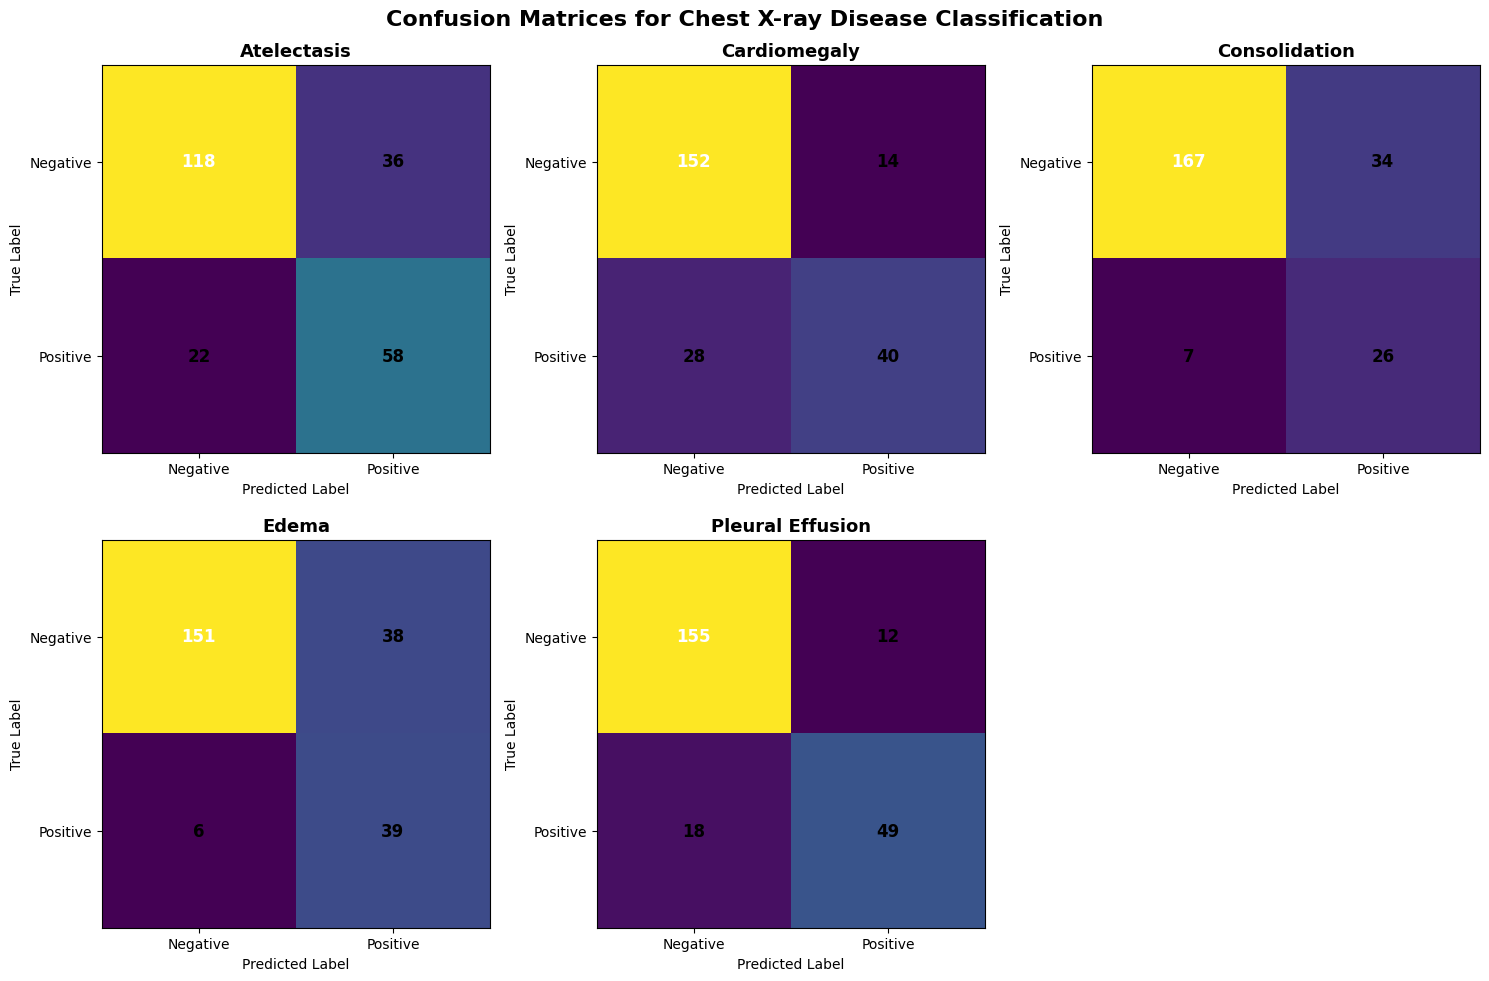

In [18]:
# Code 14: Plot confusion matrices for each disease

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create one figure with five confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for index, disease in enumerate(TARGET_DISEASES):

    cm = confusion_matrix(
        all_labels[:, index],
        all_predictions[:, index]
    )

    ax = axes[index]

    image = ax.imshow(cm)

    ax.set_title(disease, fontsize=13, fontweight="bold")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    # Display values inside each cell
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):

            ax.text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color="white" if cm[row, col] > cm.max() / 2 else "black"
            )

# Hide the unused subplot
axes[-1].axis("off")

plt.suptitle(
    "Confusion Matrices for Chest X-ray Disease Classification",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Precision-Recall Curves

Precision-Recall (PR) curves evaluate the model's performance across different classification thresholds by illustrating the trade-off between precision and recall. Unlike ROC curves, PR curves are particularly informative for imbalanced datasets, making them well suited for evaluating medical image classification models.

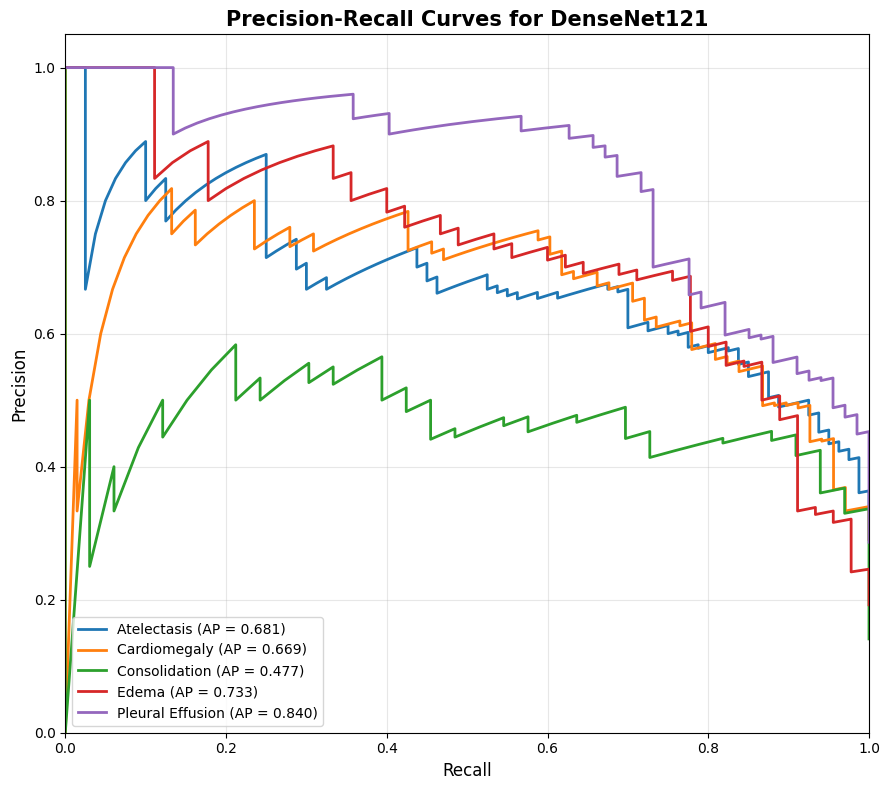

In [19]:
# Code 15: Plot Precision-Recall curves for all target diseases

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 8))

for index, disease in enumerate(TARGET_DISEASES):

    precision, recall, _ = precision_recall_curve(
        all_labels[:, index],
        all_probabilities[:, index]
    )

    average_precision = average_precision_score(
        all_labels[:, index],
        all_probabilities[:, index]
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{disease} (AP = {average_precision:.3f})"
    )

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)

plt.title(
    "Precision-Recall Curves for DenseNet121",
    fontsize=15,
    fontweight="bold"
)

plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.grid(alpha=0.3)

plt.legend(
    loc="lower left",
    fontsize=10,
    frameon=True
)

plt.tight_layout()

plt.show()

## Visualize Sample Predictions

This section displays sample chest X-ray images from the validation set along with their ground truth labels and the model's predicted probabilities. Reviewing qualitative predictions helps interpret model behavior beyond numerical evaluation metrics.

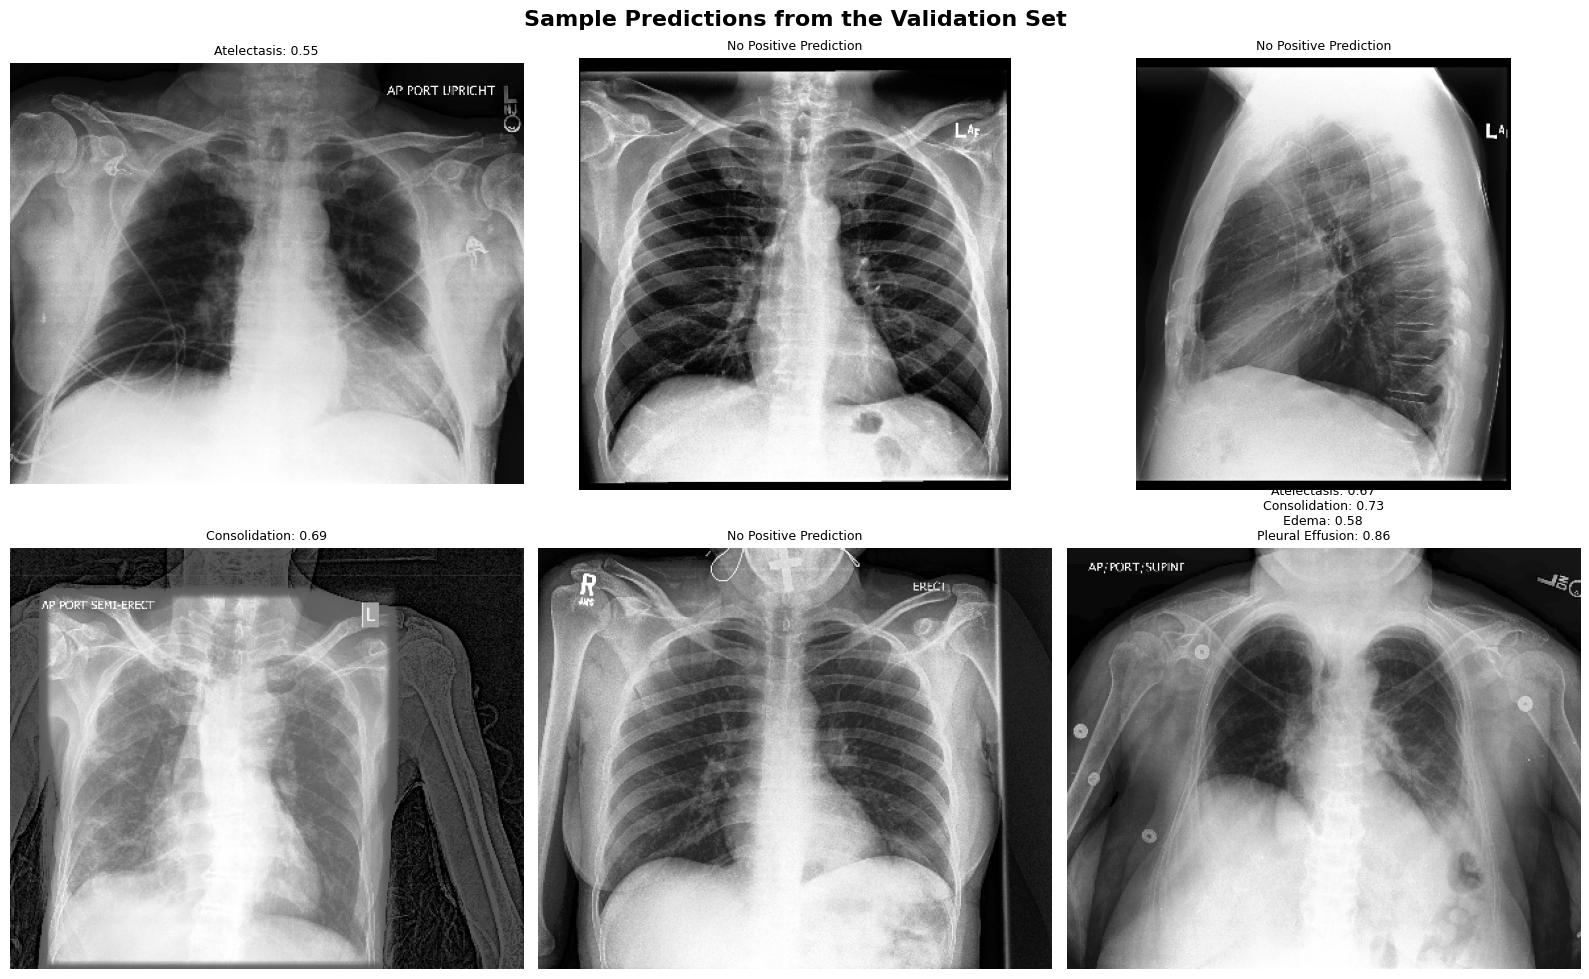

In [20]:
# Code 16: Visualize sample predictions from the validation set

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Number of samples to display
NUM_SAMPLES = 6

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i in range(NUM_SAMPLES):

    # Read image information
    row = valid_df.iloc[i]

    image_path = VALID_IMAGES_DIR / row["Path"].replace(
        "CheXpert-v1.0-small/valid/",
        ""
    )

    image = Image.open(image_path).convert("RGB")

    # Display image
    axes[i].imshow(image, cmap="gray")
    axes[i].axis("off")

    # Build prediction summary
    prediction_text = []

    for j, disease in enumerate(TARGET_DISEASES):

        probability = all_probabilities[i][j]

        if probability >= 0.5:
            prediction_text.append(
                f"{disease}: {probability:.2f}"
            )

    if len(prediction_text) == 0:
        prediction_text.append("No Positive Prediction")

    axes[i].set_title(
        "\n".join(prediction_text),
        fontsize=9
    )

plt.suptitle(
    "Sample Predictions from the Validation Set",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Analyze Misclassified Chest X-ray Images

This section identifies the validation samples where the model made incorrect predictions. Examining these cases provides valuable insights into the model's limitations and highlights examples that may require additional data, improved preprocessing, or a different decision threshold.

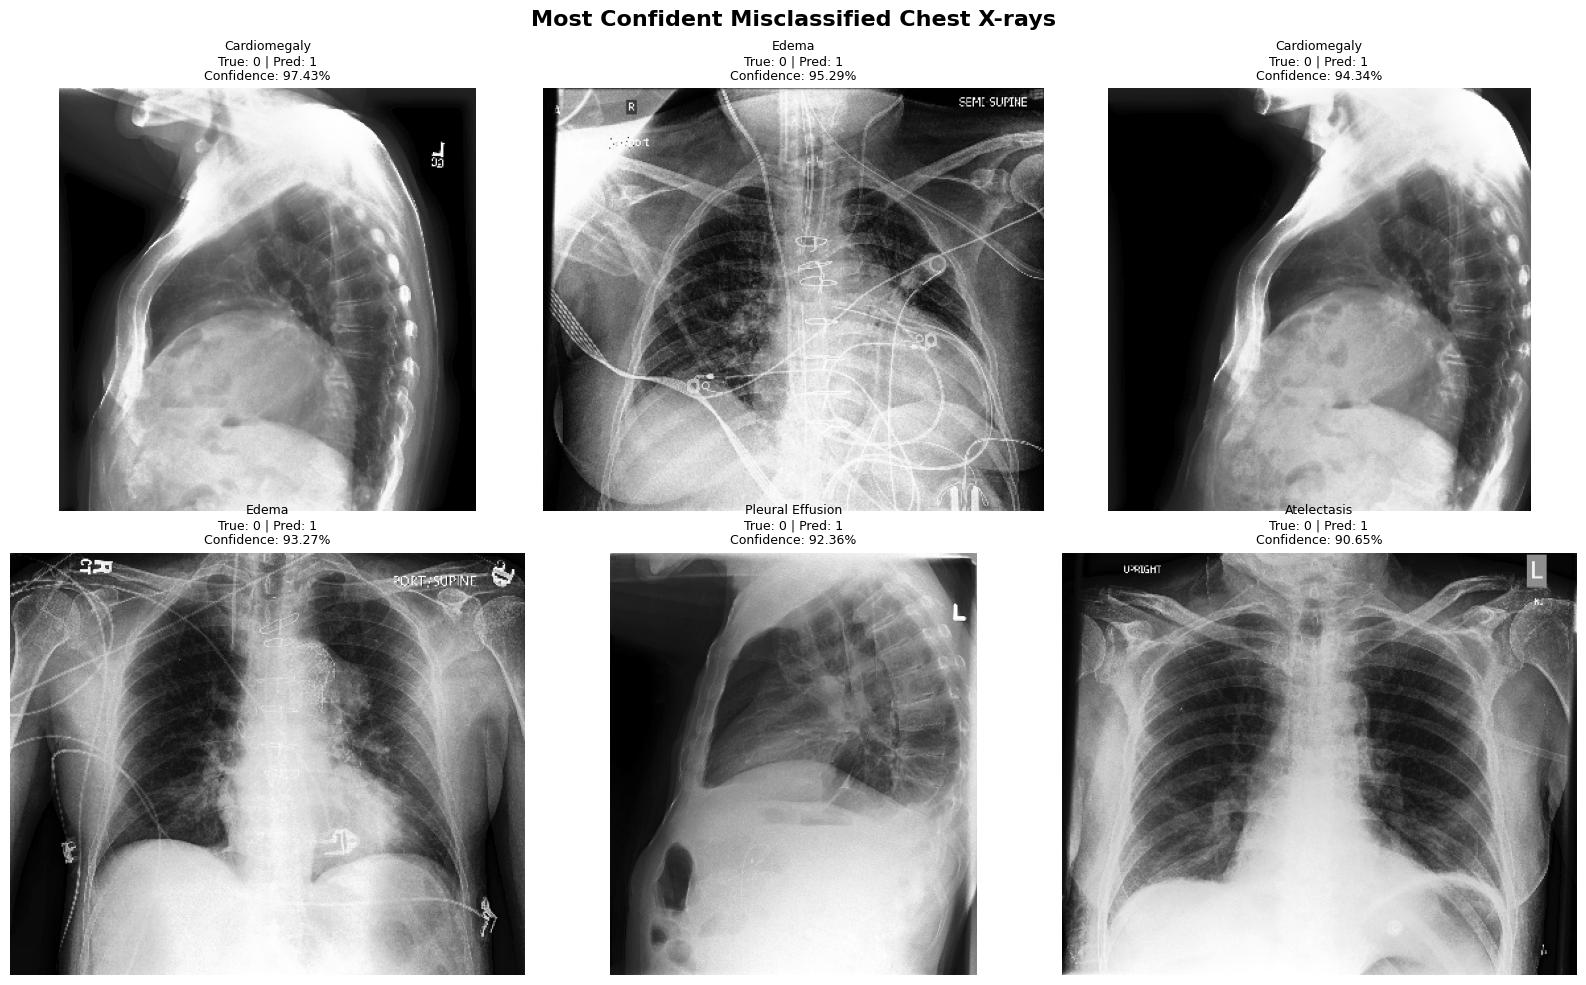

In [21]:
# Code 17: Visualize the most confident misclassified chest X-rays

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Number of misclassified samples to display
NUM_IMAGES = 6

misclassified_samples = []

# Find all incorrect predictions
for sample_index in range(len(valid_df)):

    for disease_index, disease in enumerate(TARGET_DISEASES):

        true_label = int(all_labels[sample_index, disease_index])
        predicted_label = int(all_predictions[sample_index, disease_index])

        if true_label != predicted_label:

            confidence = float(all_probabilities[sample_index, disease_index])

            misclassified_samples.append({
                "sample_index": sample_index,
                "disease": disease,
                "true_label": true_label,
                "predicted_label": predicted_label,
                "confidence": confidence
            })

# Sort by prediction confidence (highest first)
misclassified_samples = sorted(
    misclassified_samples,
    key=lambda x: x["confidence"],
    reverse=True
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for plot_index, sample in enumerate(misclassified_samples[:NUM_IMAGES]):

    row = valid_df.iloc[sample["sample_index"]]

    image_path = VALID_IMAGES_DIR / row["Path"].replace(
        "CheXpert-v1.0-small/valid/",
        ""
    )

    image = Image.open(image_path).convert("RGB")

    axes[plot_index].imshow(image, cmap="gray")
    axes[plot_index].axis("off")

    axes[plot_index].set_title(
        f"{sample['disease']}\n"
        f"True: {sample['true_label']} | Pred: {sample['predicted_label']}\n"
        f"Confidence: {sample['confidence']:.2%}",
        fontsize=9
    )

plt.suptitle(
    "Most Confident Misclassified Chest X-rays",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Explain Model Predictions using Grad-CAM

Deep learning models are often viewed as "black boxes." Grad-CAM (Gradient-weighted Class Activation Mapping) helps visualize which regions of a chest X-ray contributed most to the model's prediction.

This improves model interpretability and is widely used in medical imaging research to better understand model behavior.

In [22]:
# Code 18: Install the Grad-CAM library

# Install
!pip -q install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Grad-CAM Explainability

To better understand the model's decision-making process, Grad-CAM (Gradient-weighted Class Activation Mapping) is used to highlight the image regions that contributed most to a prediction.

The resulting heatmap is overlaid on the original chest X-ray, allowing us to visually inspect whether the model is focusing on clinically relevant areas.

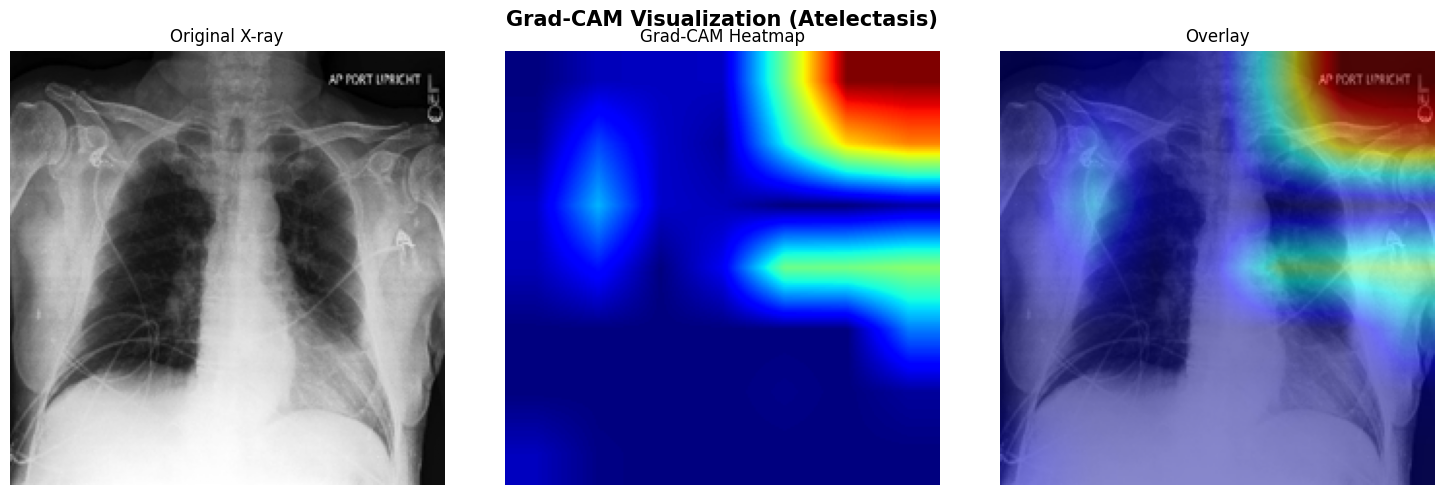

In [23]:
# Code 19: Generate a Grad-CAM visualization for a validation image

import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Select a validation image
sample_index = 0

# Read image information
row = valid_df.iloc[sample_index]

image_path = VALID_IMAGES_DIR / row["Path"].replace(
    "CheXpert-v1.0-small/valid/",
    ""
)

# Open the original image
original_image = Image.open(image_path).convert("RGB")

# Prepare the image for visualization
rgb_image = np.array(original_image.resize((224, 224))).astype(np.float32) / 255.0

# Apply the same preprocessing used during evaluation
input_tensor = validation_transform(original_image).unsqueeze(0).to(DEVICE)

# Use the last dense block of DenseNet121
target_layers = [model.features.denseblock4]

# Create the Grad-CAM object
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# Choose which disease to visualize
target_class = 0   # 0=Atelectasis, 1=Cardiomegaly, 2=Consolidation, 3=Edema, 4=Pleural Effusion

# Generate Grad-CAM
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(target_class)]
)

grayscale_cam = grayscale_cam[0]

# Overlay the heatmap
cam_image = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

# Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_image)
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cam_image)
plt.title("Overlay")
plt.axis("off")

plt.suptitle(
    f"Grad-CAM Visualization ({TARGET_DISEASES[target_class]})",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Save Evaluation Results

This section saves the generated figures and evaluation metrics to the project directory. Keeping the outputs organized makes it easier to include them in reports, presentations, and the GitHub repository.

In [24]:
# Code 20: Save evaluation metrics

from pathlib import Path

# Create output directories
OUTPUT_DIR = Path("/content/drive/MyDrive/ChestXRay_Project/outputs")
METRICS_DIR = OUTPUT_DIR / "metrics"

METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Save evaluation table
metrics_df.to_csv(
    METRICS_DIR / "evaluation_metrics.csv",
    index=False
)

print("Evaluation metrics saved successfully.")
print(f"Location: {METRICS_DIR}")

Evaluation metrics saved successfully.
Location: /content/drive/MyDrive/ChestXRay_Project/outputs/metrics


In [25]:
# Code 21: Create directories for figures

FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory created.")
print(FIGURES_DIR)

Figure directory created.
/content/drive/MyDrive/ChestXRay_Project/outputs/figures


## Final Evaluation Summary

The DenseNet121 model was evaluated on the CheXpert validation dataset for five thoracic diseases. Multiple quantitative metrics and visual analyses were used to assess model performance.

Overall, the model achieved a strong mean AUROC of **0.8790**, demonstrating reliable discrimination across the selected disease classes. In addition to numerical metrics, Grad-CAM visualizations were generated to provide insight into the regions that influenced the model's predictions, improving interpretability.

These results establish a solid baseline for future experiments involving alternative architectures, threshold optimization, and deployment.

In [26]:
# Code 22: Print the final evaluation summary

print("=" * 60)
print("Chest X-ray Disease Classification Evaluation")
print("=" * 60)

print(f"Architecture        : DenseNet121")
print(f"Validation Images   : {len(validation_dataset)}")
print(f"Target Diseases     : {len(TARGET_DISEASES)}")
print(f"Mean AUROC          : {mean_auc:.4f}")

print("\nDisease-wise AUROC")

for disease, auc in auc_scores.items():
    print(f"  {disease:<20} {auc:.4f}")

print("\nEvaluation Completed Successfully.")

Chest X-ray Disease Classification Evaluation
Architecture        : DenseNet121
Validation Images   : 234
Target Diseases     : 5
Mean AUROC          : 0.8790

Disease-wise AUROC
  Atelectasis          0.8176
  Cardiomegaly         0.8547
  Consolidation        0.8973
  Edema                0.9061
  Pleural Effusion     0.9194

Evaluation Completed Successfully.
